In [4]:
import glob
import gc
from pathlib import Path

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [17]:
## PATH & IMPORT ##

# define paths #
MASHR_PATH = Path("/mnt/sdb/scz_meta_analysis_processed/mash_results/")
MASHR_PATH = Path(MASHR_PATH)

# import mashR output files #
pm = pd.read_csv(MASHR_PATH / "mash_posterior_mean.csv", index_col=0)
lfsr = pd.read_csv(MASHR_PATH / "mash_lfsr.csv", index_col=0)
logFC_orig = pd.read_csv(MASHR_PATH / "mash_logFC_original.csv", index_col=0)
post_sd = pd.read_csv(MASHR_PATH / "mash_posterior_sd.csv", index_col=0)
neg_prob = pd.read_csv(MASHR_PATH / "mash_negative_prob.csv", index_col=0)

# import significance and missingness QC #
mash_sig_any_gene = pd.read_csv(MASHR_PATH / "mash_sig_any_gene.csv", index_col=0)
mash_sig_per_celltype = pd.read_csv(MASHR_PATH / "mash_sig_per_celltype.csv", index_col=0)
gene_missingness = pd.read_csv(MASHR_PATH / "gene_missingness.csv", index_col=0)
celltype_missingness = pd.read_csv(MASHR_PATH / "celltype_missingness.csv", index_col=0)

Index(['idiopathic_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
       'nrxn1_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
       'del22q11_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
       'del3q29_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
       'del15q13_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
       'nrxn1_GABAergic GAD1+GAD2+CALB2+',
       'del22q11_GABAergic GAD1+GAD2+CALB2+',
       'del3q29_GABAergic GAD1+GAD2+CALB2+',
       'del15q13_GABAergic GAD1+GAD2+CALB2+',
       'idiopathic_Hindbrain Neurons NR2F2+PBX3+LHX1+',
       'nrxn1_Hindbrain Neurons NR2F2+PBX3+LHX1+',
       'del22q11_Hindbrain Neurons NR2F2+PBX3+LHX1+',
       'del3q29_Hindbrain Neurons NR2F2+PBX3+LHX1+',
       'del15q13_Hindbrain Neurons NR2F2+PBX3+LHX1+',
       'nrxn1_IPC EOMES+NEUROG2+PAX6+', 'del22q11_IPC EOMES+NEUROG2+PAX6+',
       'del3q29_IPC EOMES+NEUROG2+PAX6+', 'del15q13_IPC EOMES+NEUROG2+PAX6+',
       'nrxn1_Astrocyte GFAP+AQP4+HOPX+', 'del22q11_Astrocyte GFAP+AQP4+HOPX+',
     

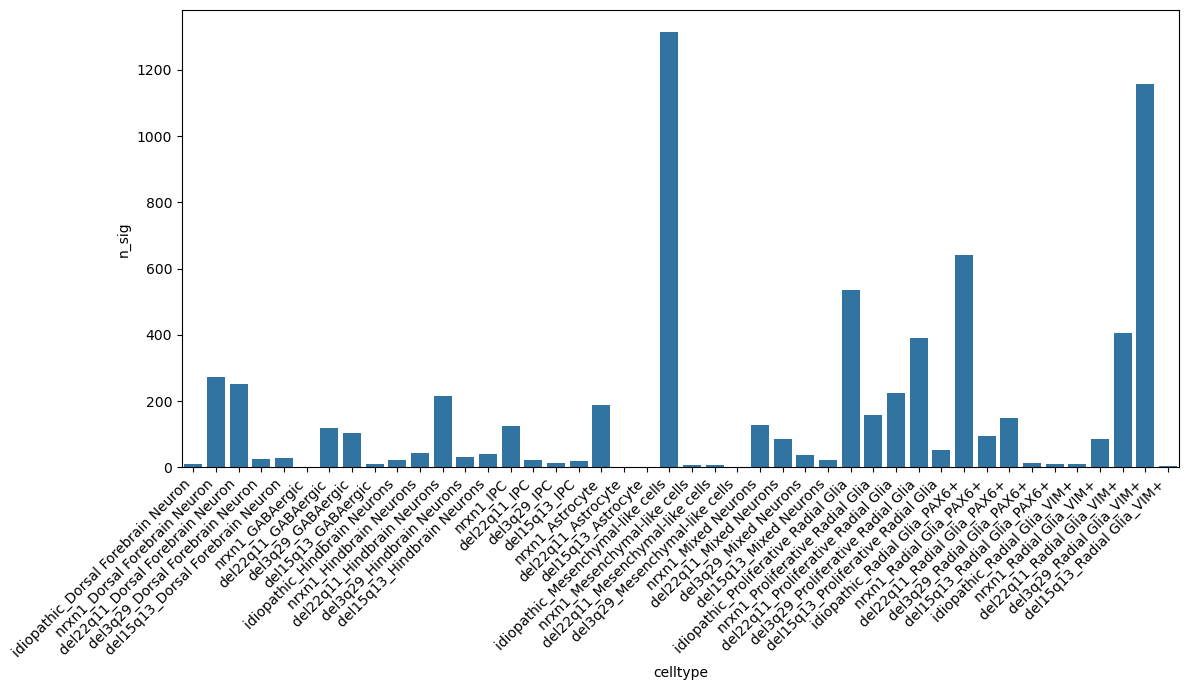

In [52]:
plt.figure(figsize=(12, 7))  # control size here

mash_sig_per_celltype_cleaned = mash_sig_per_celltype.copy()

mash_sig_per_celltype_cleaned.index = mash_sig_per_celltype_cleaned.index.str.replace('Radial Glia SOX2+VIM+FABP7+', 
                                                                                      'Radial Glia_VIM+ TEST')
mash_sig_per_celltype_cleaned.index = mash_sig_per_celltype_cleaned.index.str.replace('Radial Glia SOX2+PAX6+FABP7+', 
                                                                                      'Radial Glia_PAX6+ TEST')

mash_sig_per_celltype_cleaned.index = mash_sig_per_celltype_cleaned.index.str.split().str[:-1].str.join(" ")

sns.barplot(x=mash_sig_per_celltype_cleaned.index, y=mash_sig_per_celltype_cleaned["n_sig"])

plt.title('Significant Genes Per Celltyep
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.show()

In [30]:
mash_sig_per_celltype

,n_sig
celltype,
idiopathic_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,11
nrxn1_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,272
del22q11_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,253
del3q29_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,25
del15q13_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,30
nrxn1_GABAergic GAD1+GAD2+CALB2+,2
del22q11_GABAergic GAD1+GAD2+CALB2+,118
del3q29_GABAergic GAD1+GAD2+CALB2+,103
del15q13_GABAergic GAD1+GAD2+CALB2+,10


In [ ]:
# CAn we identify hotspots of disease acitivty within a celltype

# can we identify shared molecular programs across disease ni a given celltype #

In [27]:
(lfsr < 0.05).sum(axis=1)

1        0
2        0
3        0
4        0
5        1
        ..
11692    0
11693    0
11694    0
11695    0
11696    0
Length: 11696, dtype: int64

In [28]:
(lfsr < 0.05).sum(axis=0)

idiopathic_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+      11
nrxn1_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+          272
del22q11_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+       253
del3q29_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+         25
del15q13_Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+        30
nrxn1_GABAergic GAD1+GAD2+CALB2+                             2
del22q11_GABAergic GAD1+GAD2+CALB2+                        118
del3q29_GABAergic GAD1+GAD2+CALB2+                         103
del15q13_GABAergic GAD1+GAD2+CALB2+                         10
idiopathic_Hindbrain Neurons NR2F2+PBX3+LHX1+               22
nrxn1_Hindbrain Neurons NR2F2+PBX3+LHX1+                    44
del22q11_Hindbrain Neurons NR2F2+PBX3+LHX1+                216
del3q29_Hindbrain Neurons NR2F2+PBX3+LHX1+                  31
del15q13_Hindbrain Neurons NR2F2+PBX3+LHX1+                 42
nrxn1_IPC EOMES+NEUROG2+PAX6+                              124
del22q11_IPC EOMES+NEUROG2+PAX6+                       

In [13]:
# mash_posterior_mean.csv (pm)

# What it is:

# The main result of the analysis

# Meaning:

# For every gene × cell type:

# estimated log fold-change after borrowing information across all genes and cell types
# “best guess effect size” from mash
# Intuition:

# “What is the true effect size, after smoothing/shrinkage?”

# 🎯 2. mash_lfsr.csv (lfsr)
# What it is:

# uncertainty-adjusted significance

# Meaning:

# For each gene × cell type:

# probability the sign of the effect is wrong
# lower = more confident signal
# How to read it:
# < 0.05 → strong evidence gene is truly up/down
# ~0.5 → no real signal
# Intuition:

# “How confident are we that this effect is real and in the correct direction?”

# 📊 3. mash_logFC_original.csv (orig)
# What it is:

# raw dreamlet estimates before mash

# Meaning:
# per gene × cell type logFC
# noisy
# incomplete (NA where gene not expressed / not tested)
# Intuition:

# “What the data says before statistical borrowing/smoothing”

# 📉 4. mash_posterior_sd.csv
# What it is:

# uncertainty of the effect size

# Meaning:
# how wide the posterior distribution is for each estimate
# high SD = uncertain estimate
# Intuition:

# “How precise is each effect size?”

# ⚠️ 5. mash_negative_prob.csv
# What it is:

# direction uncertainty

# Meaning:
# probability effect is negative (vs positive)
# near 0 or 1 = confident direction
# near 0.5 = unsure
# Intuition:

# “How certain is the direction (up vs down)?”

# 🧬 6. mash_sig_any_gene.csv
# What it is:

# gene-level summary of significance

# Meaning:
# TRUE if gene is significant in at least one cell type
# Intuition:

# “Does this gene matter anywhere?”

# 🧪 7. mash_sig_per_celltype.csv
# What it is:

# cell-type-level summary

# Meaning:
# number of significant genes per cell type
# Intuition:

# “Which cell types show strongest signal?”

# 🧾 8. gene_missingness.csv
# What it is:

# data quality per gene

# Meaning:
# fraction of missing values per gene
# Intuition:

# “Which genes are poorly observed / sparse?”

# 🧾 9. celltype_missingness.csv
# What it is:

# data quality per cell type

# Meaning:
# fraction of missing genes per cell type
# Intuition:

# “Which cell types are sparse or low-quality?”

# 🧠 Big picture (how all of it fits together)

# You now have 3 layers:

# 🔵 Layer 1 — Raw signal
# logFC_original

# noisy biology

# 🟢 Layer 2 — Model estimate
# posterior_mean (pm)
# posterior_sd

# best estimate of effect + uncertainty

# 🔴 Layer 3 — Decision / significance
# lfsr
# sig_any_gene
# sig_per_celltype

# what you would report as “findings”

# 🚀 One-line summary

# You saved raw effects, shrinkage-adjusted effects, uncertainty, and significance — i.e. everything needed for full biological interpretation + plotting + downstream ML.